# Refined Stage 3B - context sweep (RQ2)

How much history does each signal need? Context is swept **in steps**, which is the model's
actual knob and keeps the design balanced. Horizon is held fixed.

Three design rules make the sweep interpretable:

1. **Anchored origins.** Every context setting forecasts the identical target windows.
   Without this, a longer context starts forecasting later and you are comparing different
   test sets.
2. **Fixed MASE denominator.** The scale is computed per (series, granularity) and reused
   at every context, so a change in MASE is a change in forecast quality — not a change in
   the normaliser. This is the trap that would otherwise manufacture a fake confirmation of
   H3 at 1-minute wind, where the old code flipped `m` from 1 to 1440 mid-sweep.
3. **Planned window counts** — new in this version, and the one that changed an answer.

> ### Why this notebook was rebuilt
>
> The first version used `N_WINDOWS = 5` for every cell. That is under-powered, and it is
> unequal: one window spans `horizon × step_minutes` of real time, so five 24-step windows
> is 2.5 days of 30-minute load data and **2 hours** of 1-minute wind.
>
> Stage 3H re-ran overlapping cells with 30–120 windows and the conclusion moved:
>
> | cell (horizon 24) | 5 windows | 30–120 windows |
> |---|---|---|
> | load native, 128 → 1024 | 1.135 → 1.197 (**−2.4%**) | 1.043 → 0.735 (**+29.5%**) |
> | solar native, 128 → 1024 | 1.057 → 1.288 (−3.9%) | 1.732 → 1.385 (**+20.0%**) |
> | wind native, 128 → 1024 | 0.725 → 0.671 (+9.0%) | 0.629 → 0.647 (−2.9%) |
>
> "More context does not help" was an artefact of the window count, not a property of the
> models. The previous CSV is archived as `refined_stage3b_context_sweep_5window.csv` and
> section 4 compares the two directly — that comparison belongs in the methodology chapter.

> **One load, not one load per configuration.** Every window for every configuration is
> built first, then scored in a single pass. `C.run()` holds one model in memory at a time
> and iterates the whole list, so this notebook loads three models in total. The earlier
> pattern -- `C.run()` inside the sweep loop -- reloaded all three on every iteration,
> which in 3H meant 144 load/free cycles to support 27 minutes of inference.

In [1]:
import sys, os, shutil, warnings, importlib
warnings.filterwarnings("ignore")
sys.path.insert(0, os.getcwd())
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import refined_stage_common as C

# A kernel that imported an older refined_stage_common keeps serving it from cache, and
# the failure surfaces much later as a missing column. Reload, then verify.
importlib.reload(C)
REQUIRED = "2026.09.10-relmae"
assert getattr(C, "__version__", None) == REQUIRED, (
    f"stale refined_stage_common (got {getattr(C, '__version__', 'none')}, "
    f"need {REQUIRED}) -- restart the kernel and Run All")
assert "plan_windows" in getattr(C, "__features__", set()), (
    "refined_stage_common predates the window planner -- restart the kernel and Run All")

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)
PALETTE = {"chronos": "#2563eb", "timesfm": "#059669", "moirai": "#d97706"}
print(f"common module {C.__version__} from {C.__file__}")

common module 2026.09.10-relmae from e:\Thesis\EnergyForcastModel\refined_stage_common.py


In [2]:
DATA = C.get_data()

MIN_CTX = C.min_context_for(("chronos", "timesfm", "moirai"))   # TimesFM patches in 32s

def archive(path, tag):
    """Keep the previous (5-window) result next to the new one instead of overwriting it.

    The comparison between the two is itself a methodological finding, so the old file is
    evidence, not clutter.
    """
    old = path.replace(".csv", f"_{tag}.csv")
    if os.path.exists(path) and not os.path.exists(old):
        shutil.copy2(path, old)
        print(f"archived previous result -> {old}")

def shortest_series(etype, gran):
    return min(len(v) for v in C.panel(DATA, etype, gran))

def cell_geometry(etype, gran, horizon, ctx_cap, min_windows, min_days, max_windows,
                  ladder=(20, 10, 5)):
    """Pick (context, n_windows) for one cell from the series length it actually has.

    Context is taken as large as the cap allows while still leaving room for `min_windows`
    of targets. A 365-point daily solar series cannot reserve 30 x 24 target steps AND hold
    a usable context, so the window requirement steps down a ladder until something fits --
    and the rung it settles on is recorded, so the compromise appears in the table rather
    than being silently made.

    Returns None when no rung leaves a context the models can accept.
    """
    d = C.step_minutes(etype, gran)
    shortest = shortest_series(etype, gran)
    want = C.windows_for(etype, gran, horizon, min_windows, min_days, max_windows)
    c = k = None
    for rung in [min_windows] + [r for r in ladder if r < min_windows]:
        cc = min(int(ctx_cap), shortest - rung * int(horizon))
        if cc >= MIN_CTX:
            c, k = int(cc), int(rung)
            break
    if c is None:
        return None
    supply = (shortest - c) // int(horizon)
    n = int(min(want, supply))
    if n < 1:
        return None
    ev = n * int(horizon) * d
    return {"etype": etype, "gran": gran, "horizon_steps": int(horizon), "context": c,
            "window_floor_used": k, "wanted": int(want), "series_supports": int(supply),
            "n_windows": n, "evaluated_min": ev, "evaluated": C.human_duration(ev),
            "meets_floors": bool(n >= min_windows and ev >= min_days * 1440)}

def show_plan(rows, min_windows, min_days, cols=None):
    tab = pd.DataFrame(rows)
    cols = cols or ["etype", "gran", "context", "horizon_steps", "wanted",
                    "series_supports", "n_windows", "evaluated", "meets_floors"]
    print(tab[cols].to_string(index=False))
    bad = tab[~tab.meets_floors]
    if len(bad):
        print(f"\n{len(bad)} cell(s) cannot meet both floors (>= {min_windows} windows "
              f"AND >= {min_days} days). Report them as such -- do not quietly drop them:")
        print(bad[["etype", "gran", "n_windows", "evaluated"]].to_string(index=False))
    return tab

loaded cached panel <- refined_panel_cache.pkl
  load   5 series, 230,736–232,272 points
  solar  5 series, 52,560–52,560 points
  wind   5 series, 434,876–434,876 points


## 1. The plan read this table before running anything

`context` is capped per cell by the shortest series in it: a 365-point daily solar series
cannot hold a 2,048-step context. `evaluated` is the real time the forecasts in that cell
will cover. `meets_floors` is False where the data physically cannot support both floors,
and those cells are reported rather than dropped.

In [3]:
CTX_GRID = [128, 256, 512, 1024, 2048]
HORIZON  = 24        # steps, held fixed across the whole sweep

# 30 windows keeps the paired Wilcoxon in section 5 viable; 14 days keeps a recommendation
# from resting on one afternoon; the cap keeps the sweep affordable, because 1-minute wind
# at a 24-step horizon would otherwise need 840 windows per cell to reach 14 days.
MIN_WINDOWS, MIN_DAYS, MAX_WINDOWS = 30, 14.0, 90

rows = []
for et in C.BASE:
    for gk in C.GRANULARITIES:
        p = cell_geometry(et, gk, HORIZON, max(CTX_GRID),
                          MIN_WINDOWS, MIN_DAYS, MAX_WINDOWS)
        if p is None:
            print(f"  {et}/{gk}: series too short for any usable context — excluded")
            continue
        p["swept"] = [c for c in CTX_GRID if MIN_CTX <= c <= p["context"]]
        rows.append(p)
PLAN = show_plan(rows, MIN_WINDOWS, MIN_DAYS,
                 cols=["etype", "gran", "context", "swept", "wanted", "series_supports",
                       "n_windows", "evaluated", "meets_floors"])

# A cell whose ceiling sits below the smallest grid context cannot be swept at all. Daily
# solar and daily wind are one calendar year long (365 and 302 points), so once 30 x 24
# target steps are reserved there is no room for a 128-step context, let alone a range of
# them. That is a property of the archive, not a choice — say so in the thesis and answer
# the daily-granularity question from 3D, where the design is stated in physical time.
NOSWEEP = PLAN[PLAN.swept.map(len) < 2]
if len(NOSWEEP):
    print("\nExcluded from the sweep — fewer than two grid contexts fit under the ceiling:")
    for r in NOSWEEP.itertuples():
        print(f"  {r.etype}/{r.gran}: ceiling {r.context} steps "
              f"({C.human_duration(r.context * C.step_minutes(r.etype, r.gran))} of history)"
              f", grid contexts that fit: {r.swept}")
PLAN = PLAN[PLAN.swept.map(len) >= 2].reset_index(drop=True)

# Each cell is swept only up to its own ceiling, and anchored there, so that every context
# inside a cell forecasts the identical targets.
CAP = {(r.etype, r.gran): r.context for r in PLAN.itertuples()}
NW  = {(r.etype, r.gran): r.n_windows for r in PLAN.itertuples()}

etype   gran  context                       swept  wanted  series_supports  n_windows evaluated  meets_floors
 load native     2048 [128, 256, 512, 1024, 2048]      30             9528         30    15.0 d          True
 load     1h     2048 [128, 256, 512, 1024, 2048]      30             4721         30    30.0 d          True
 load     1D     2048 [128, 256, 512, 1024, 2048]      30              114         30   720.0 d          True
solar native     2048 [128, 256, 512, 1024, 2048]      84             2104         84    14.0 d          True
solar     1h     2048 [128, 256, 512, 1024, 2048]      30              279         30    30.0 d          True
solar     1D      125                          []      30               10         10   240.0 d         False
 wind native     2048 [128, 256, 512, 1024, 2048]      90            18034         90     1.5 d         False
 wind     1h     2048 [128, 256, 512, 1024, 2048]      30              216         30    30.0 d          True
 wind     

## 2. Build every window, then score once

In [4]:
archive("refined_stage3b_context_sweep.csv", "5window")

ALL = []
for (et, gk), cap in sorted(CAP.items()):
    n = NW[(et, gk)]
    used = [c for c in CTX_GRID if MIN_CTX <= c <= cap]
    if not used:
        print(f"  {et}/{gk}: no grid context fits under ceiling {cap} — skipped"); continue
    for ctx in used:
        W = C.build_windows(DATA, context_steps=ctx, horizon_steps=HORIZON, n_windows=n,
                            etypes=[et], granularities=[gk],
                            anchor_context=cap,      # origins identical at every context
                            verbose=False)
        ALL.extend(W)
    print(f"  {et:6s}/{gk:7s} contexts {used} x {n} windows x 5 series")

ALL.sort(key=lambda w: (w.context_steps, w.horizon_steps))   # keeps Moirai's cache warm
pairs = len({(w.context_steps, w.horizon_steps) for w in ALL})
print(f"\n{len(ALL):,} windows across {pairs} (context, horizon) pairs "
      f"-> {len(ALL)*3:,} forecasts, 3 model loads.")
print(f"   the old pattern would have loaded {pairs*3} times for the same work.")
print(f"   rough estimate at 0.05-0.15 s per forecast: "
      f"{len(ALL)*3*0.05/60:.0f}-{len(ALL)*3*0.15/60:.0f} min")

MODELS = C.make_models(("chronos", "timesfm", "moirai"))
MODELS["moirai"].max_cached = 48    # one forecaster per (horizon, context); they share the
                                    # loaded module, so caching them costs almost no memory

sweep = C.run(MODELS, ALL)
C.save(sweep, "refined_stage3b_context_sweep.csv")

archived previous result -> refined_stage3b_context_sweep_5window.csv
  load  /1D      contexts [128, 256, 512, 1024, 2048] x 30 windows x 5 series
  load  /1h      contexts [128, 256, 512, 1024, 2048] x 30 windows x 5 series
  load  /native  contexts [128, 256, 512, 1024, 2048] x 30 windows x 5 series
  solar /1h      contexts [128, 256, 512, 1024, 2048] x 30 windows x 5 series
  solar /native  contexts [128, 256, 512, 1024, 2048] x 84 windows x 5 series
  wind  /1h      contexts [128, 256, 512, 1024, 2048] x 30 windows x 5 series
  wind  /native  contexts [128, 256, 512, 1024, 2048] x 90 windows x 5 series

8,100 windows across 5 (context, horizon) pairs -> 24,300 forecasts, 3 model loads.
   the old pattern would have loaded 15 times for the same work.
   rough estimate at 0.05-0.15 s per forecast: 20-61 min
loading chronos (max_context=2048, max_horizon=24) ...


chronos: 100%|██████████| 8100/8100 [02:27<00:00, 54.99it/s]


  chronos: 8100/8100 scored | 0.10 GB -> freeing
loading timesfm (max_context=2048, max_horizon=24) ...
    timesfm API = 2p5  (max_context=2048, max_horizon=24)


timesfm: 100%|██████████| 8100/8100 [40:51<00:00,  3.30it/s]  

  timesfm: 8100/8100 scored | 0.93 GB -> freeing
loading moirai (max_context=2048, max_horizon=24) ...



moirai: 100%|██████████| 8100/8100 [04:18<00:00, 31.32it/s]


  moirai: 8100/8100 scored | 0.06 GB -> freeing

NaN rate per model:
  chronos    0.0%
  moirai     0.0%
  timesfm    0.0%

All windows scored.
24,300 rows -> refined_stage3b_context_sweep.csv  (5.72 MB)


'refined_stage3b_context_sweep.csv'

## 3. The response curves

In [5]:
cl = C.clean(sweep)
curve = (cl.groupby(["etype", "gran_label", "model", "context_steps"])["relMAE"]
           .median().reset_index())
print(curve.pivot_table(index=["etype", "gran_label", "model"],
                        columns="context_steps", values="relMAE").round(3).to_string())

18,675/24,300 windows used | 5625 degenerate excluded
context_steps                    128    256    512    1024   2048
etype gran_label       model                                     
load  daily            chronos  0.872  0.855  0.775  0.751  0.763
                       moirai   1.000  1.000  0.950  0.905  0.931
                       timesfm  0.729  0.653  0.471  0.337  0.278
      hourly           chronos  0.883  0.787  0.708  0.756  0.743
                       moirai   1.169  1.095  1.041  1.073  1.021
                       timesfm  0.988  0.849  0.850  0.909  0.885
      minutes (native) chronos  0.959  0.941  0.786  0.669  0.590
                       moirai   1.827  1.695  1.506  1.535  1.516
                       timesfm  0.824  0.663  0.556  0.461  0.406
solar hourly           chronos  0.962  0.955  0.937  0.973  0.944
                       moirai   1.384  1.257  1.156  1.159  1.221
                       timesfm  1.096  1.097  1.054  1.157  1.101
      minutes (native)

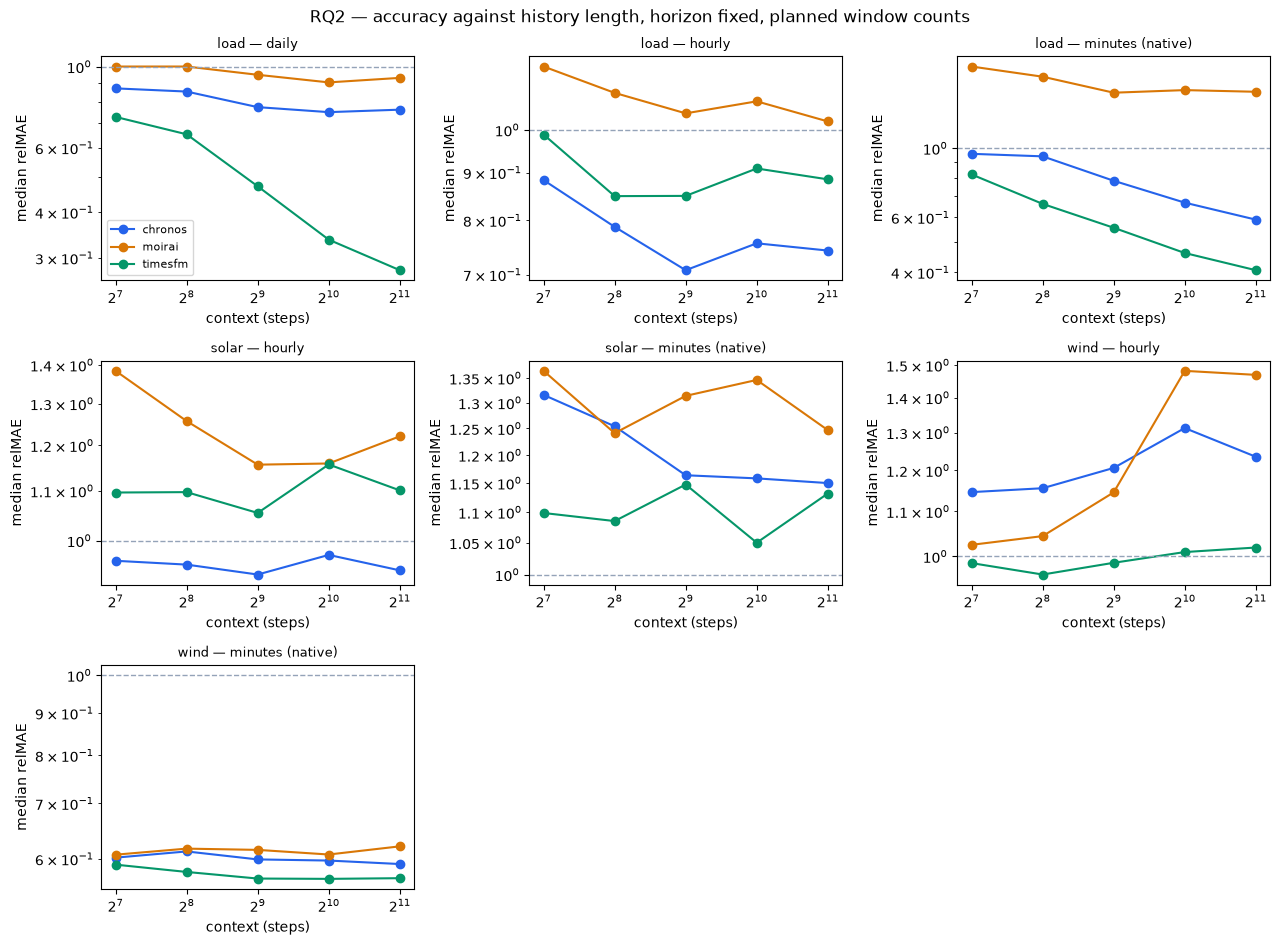

In [6]:
cells = curve.groupby(["etype", "gran_label"]).size().index.tolist()
n = len(cells); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.3*ncol, 3.2*nrow), squeeze=False)
for ax, (et, gl) in zip(axes.ravel(), cells):
    sub = curve[(curve.etype == et) & (curve.gran_label == gl)]
    for mdl, g in sub.groupby("model"):
        ax.plot(g.context_steps, g.relMAE, marker="o", label=mdl, color=PALETTE.get(mdl))
    ax.axhline(1.0, color="#94a3b8", ls="--", lw=1)
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_title(f"{et} — {gl}", fontsize=9)
    ax.set_xlabel("context (steps)"); ax.set_ylabel("median relMAE")
for ax in axes.ravel()[n:]:
    ax.axis("off")
axes[0][0].legend(fontsize=8)
plt.suptitle("RQ2 — accuracy against history length, horizon fixed, planned window counts")
plt.tight_layout(); plt.show()

## 4. Does the window count change the answer?

This is the cell to quote in the methodology chapter. It re-reads the archived 5-window run
and puts the two gradients side by side. A sign flip means the earlier conclusion was an
artefact of evaluation coverage, not a property of the models — which is a finding about
**how** zero-shot forecasters must be evaluated, not just about how they perform.

In [7]:
OLD = "refined_stage3b_context_sweep_5window.csv"
if os.path.exists(OLD):
    old = C.clean(pd.read_csv(OLD), verbose=False)
    def gradient(df):
        g = (df.groupby(["etype", "gran_label", "context_steps"])["relMAE"]
               .median().reset_index())
        out = []
        for (et, gl), s in g.groupby(["etype", "gran_label"]):
            s = s.sort_values("context_steps")
            lo, hi = s.relMAE.iloc[0], s.relMAE.iloc[-1]
            out.append({"etype": et, "gran_label": gl,
                        "ctx_lo": int(s.context_steps.iloc[0]),
                        "ctx_hi": int(s.context_steps.iloc[-1]),
                        "relMAE_lo": lo, "relMAE_hi": hi,
                        "improvement_pct": 100 * (lo - hi) / lo if lo else np.nan})
        return pd.DataFrame(out)

    a = gradient(old).rename(columns={"improvement_pct": "old_5win",
                                      "relMAE_lo": "old_lo", "relMAE_hi": "old_hi"})
    b = gradient(cl).rename(columns={"improvement_pct": "new_planned",
                                     "relMAE_lo": "new_lo", "relMAE_hi": "new_hi"})
    cmp = a.merge(b, on=["etype", "gran_label"], suffixes=("_o", "_n"))
    # a genuine reversal needs both gradients non-zero and pointing opposite ways
    cmp["sign_flip"] = (np.sign(cmp.old_5win.round(6))
                        * np.sign(cmp.new_planned.round(6))) < 0
    show = ["etype", "gran_label", "old_lo", "old_hi", "old_5win",
            "new_lo", "new_hi", "new_planned", "sign_flip"]
    print("Percent improvement in median relMAE from the smallest to the largest context:")
    print(cmp[show].round(3).to_string(index=False))
    print(f"\n{int(cmp.sign_flip.sum())} of {len(cmp)} cells change sign when the window "
          f"count is planned rather than fixed at 5.")
    cmp.to_csv("refined_stage3b_window_count_sensitivity.csv", index=False)
else:
    print(f"{OLD} not present — nothing to compare against. This is expected on a first run.")

Percent improvement in median relMAE from the smallest to the largest context:
etype       gran_label  old_lo  old_hi  old_5win  new_lo  new_hi  new_planned  sign_flip
 load            daily   0.938   0.803    14.447   0.851   0.605       28.914      False
 load           hourly   1.057   0.827    21.743   0.979   0.862       11.949      False
 load minutes (native)   1.135   1.162    -2.376   1.043   0.719       31.077       True
solar           hourly   0.983   1.056    -7.435   1.146   1.110        3.173       True
solar minutes (native)   1.057   1.098    -3.913   1.193   1.158        2.995       True
 wind           hourly   1.039   1.139    -9.634   1.040   1.224      -17.683      False
 wind minutes (native)   0.725   0.660     8.959   0.594   0.593        0.146      False

3 of 7 cells change sign when the window count is planned rather than fixed at 5.


## 5. C_deploy and C_saturate

In [8]:
from scipy.stats import wilcoxon

out = []
for (et, gk, mdl), g in cl.groupby(["etype", "gran", "model"]):
    piv = g.pivot_table(index=["series_id", "origin_index"],
                        columns="context_steps", values="relMAE")
    ctxs = sorted(piv.columns)
    if not ctxs:
        continue
    meds = {c: piv[c].median() for c in ctxs}
    deploy = next((c for c in ctxs if meds[c] < 1.0), None)
    sat, n_pairs = ctxs[-1], {}
    for a, bb in zip(ctxs, ctxs[1:]):
        pair = piv[[a, bb]].dropna()
        n_pairs[(a, bb)] = len(pair)
        if len(pair) < 6:
            continue
        try:
            p = wilcoxon(pair[a], pair[bb]).pvalue
        except ValueError:      # all differences zero
            p = 1.0
        if p >= 0.05:           # no significant gain from a -> bb
            sat = a
            break
    d = C.step_minutes(et, gk)
    finite = [v for v in meds.values() if np.isfinite(v)]
    out.append({"etype": et, "gran": gk, "model": mdl,
                "C_deploy": deploy,
                "deploy_history": C.human_duration(deploy * d) if deploy else "never < 1.0",
                "C_saturate": sat,
                "saturate_history": C.human_duration(sat * d),
                "best_relMAE": round(min(finite), 3) if finite else np.nan,
                "median_pairs": int(np.median(list(n_pairs.values()))) if n_pairs else 0})
dep = pd.DataFrame(out).sort_values(["etype", "gran", "model"])
print(dep.to_string(index=False))
dep.to_csv("refined_stage3b_context_requirements.csv", index=False)
print("\nmedian_pairs is the number of paired observations behind each Wilcoxon test.")
print("In the 5-window version this was 25; anything below ~20 cannot detect a small effect.")

etype   gran   model  C_deploy deploy_history  C_saturate saturate_history  best_relMAE  median_pairs
 load     1D chronos     128.0        128.0 d         128          128.0 d        0.751           150
 load     1D  moirai     512.0        512.0 d         128          128.0 d        0.905           150
 load     1D timesfm     128.0        128.0 d        2048         2048.0 d        0.278           150
 load     1h chronos     128.0          5.3 d         128            5.3 d        0.708           150
 load     1h  moirai       NaN    never < 1.0         256           10.7 d        1.021           150
 load     1h timesfm     128.0          5.3 d         256           10.7 d        0.849           150
 load native chronos     128.0          2.7 d         128            2.7 d        0.590           150
 load native  moirai       NaN    never < 1.0         256            5.3 d        1.506           150
 load native timesfm     128.0          2.7 d         512           10.7 d        

`C_deploy` answers *how much history do I need before this is usable*, in real time units.
`C_saturate` answers *is more history worth paying for*. Report the operator-safe figure as
the value at which the **worst** series in the cell passes, not the median — a
recommendation that only works on the easiest site is not a recommendation.

Section 4 must be reported alongside them. If a cell's gradient flipped sign, the honest
statement is that the context effect at that granularity is not robust to evaluation
coverage, and the planned-window figure is the one to quote.

Re-run `refined_stage3e_significance` and `refined_stage3f_selection_matrix` after this
notebook — both read `refined_stage3b_context_sweep.csv`.

Next: `refined_stage3c_horizon_sweep`.